In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("kc_house_data.zip")
X= df.drop(columns = ["id", "price","date"])
y= df["price"]
X_shape=X.shape
print("Numero de colunas= ", X_shape[1])

Numero de colunas=  18


In [19]:
print("Numero de observações" ,X_shape[0])

Numero de observações 21613


In [20]:
X.isnull().sum()

bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


                     id     price  bedrooms  bathrooms  sqft_living  sqft_lot  \
id             1.000000 -0.016762  0.001286   0.005160    -0.012258 -0.132109   
price         -0.016762  1.000000  0.308350   0.525138     0.702035  0.089661   
bedrooms       0.001286  0.308350  1.000000   0.515884     0.576671  0.031703   
bathrooms      0.005160  0.525138  0.515884   1.000000     0.754665  0.087740   
sqft_living   -0.012258  0.702035  0.576671   0.754665     1.000000  0.172826   
sqft_lot      -0.132109  0.089661  0.031703   0.087740     0.172826  1.000000   
floors         0.018525  0.256794  0.175429   0.500653     0.353949 -0.005201   
waterfront    -0.002721  0.266369 -0.006582   0.063744     0.103818  0.021604   
view           0.011592  0.397293  0.079532   0.187737     0.284611  0.074710   
condition     -0.023783  0.036362  0.028472  -0.124982    -0.058753 -0.008958   
grade          0.008130  0.667434  0.356967   0.664983     0.762704  0.113621   
sqft_above    -0.010842  0.6

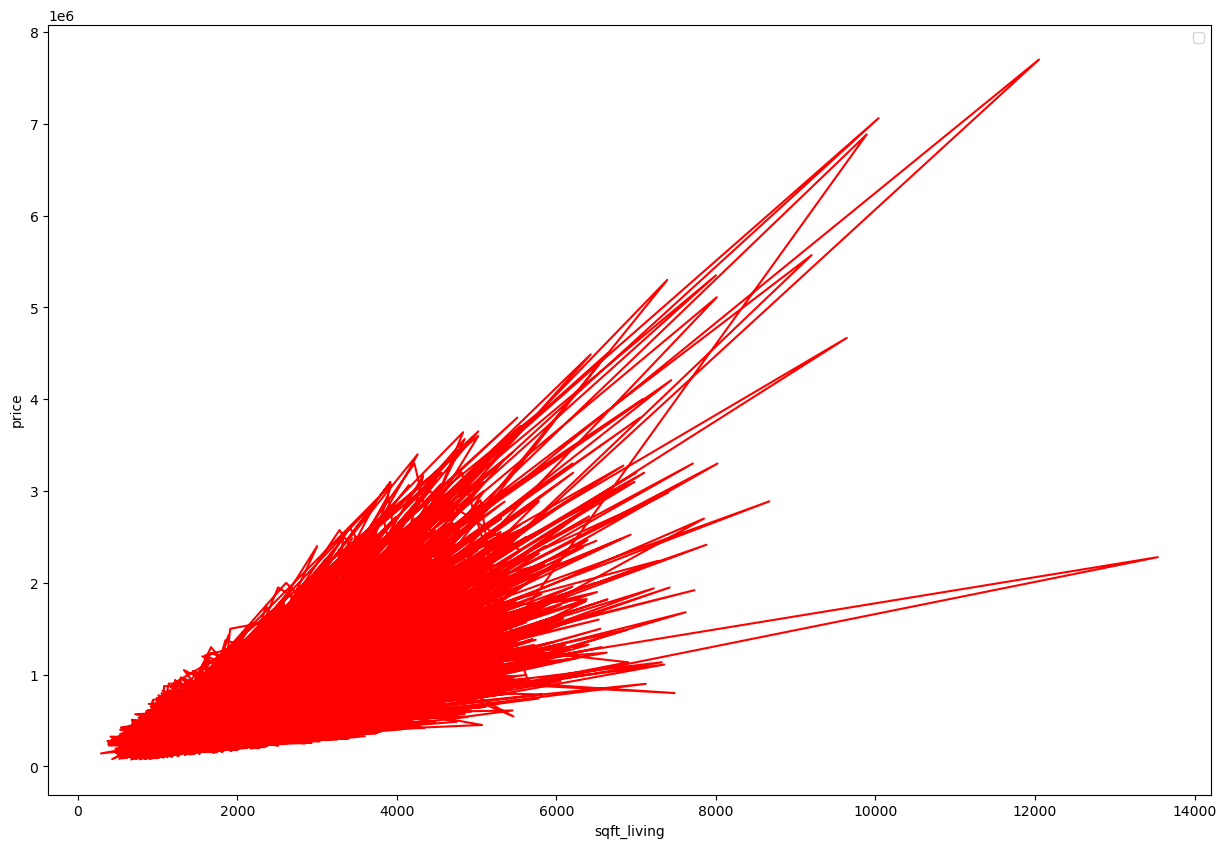

In [46]:
X = df["sqft_living"]
#df = df.drop('yr_built', axis=1)
#print(df.head())
#corr= df.corrwith( df.sqft_lot15 ,axis=0)
#sorted_corr = corr.unstack().sort_values()
#print(sorted_corr)
print(df.corr())
df_corr_impact_action_yn = df[df.columns[0:17]].corr()['sqft_living'][:-1]
#set fig size
fig, ax = plt.subplots(figsize=(15,10))
#plot matrix
plt.plot(X, y, 'r')
plt.xlabel('sqft_living')
plt.ylabel('price')
plt.legend()
#sns.heatmap(df_corr_impact_action_yn.to_frame(),annot=True, annot_kws={'size':12},cmap="GnBu")
plt.show()

In [48]:
from sklearn.linear_model import LinearRegression

X = df.sqft_living.values.reshape(-1,1)
y = df.price.values.reshape(-1,1)

In [50]:
from numpy.linalg import pinv
X_bias = np.c_[np.ones((len(X),1)),X]
    
theta_pinv = pinv(X_bias).dot(y)

print(theta_pinv)

[[-43580.74309447]
 [   280.6235679 ]]


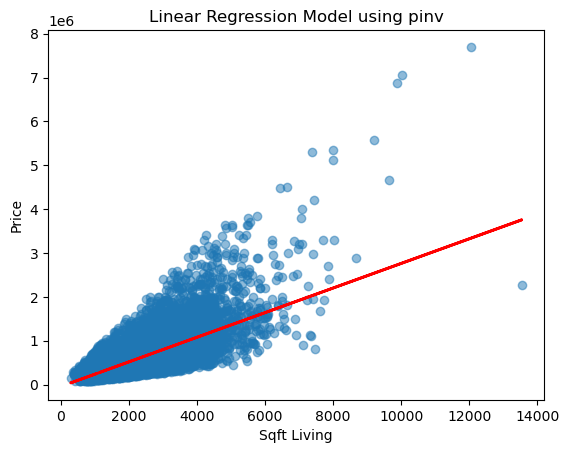

In [51]:
plt.scatter(X, y, alpha=0.5)
plt.plot(X, X_bias.dot(theta_pinv), color='red', linewidth=2)
plt.title('Linear Regression Model using pinv')
plt.xlabel('Sqft Living')
plt.ylabel('Price')
plt.show()  

In [53]:
X = df.sqft_living.values.reshape(-1,1)
y= df.price.values.reshape(-1,1)

model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [56]:
model.score(X,y)

0.4928532179037931

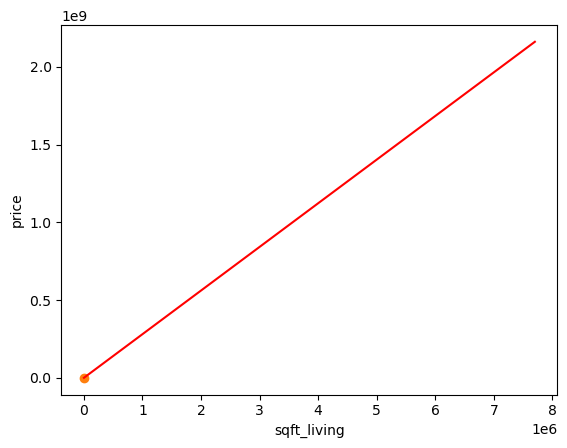

In [60]:
fig, ax = plt.subplots(1, 1)
ax.scatter(X,y, s=1)
min_area = X.min()
max_area = y.max()
xs = np.arange(min_area,max_area)
ys = model.predict(xs.reshape(-1,1))
ax.plot(xs, ys, c='r')
ax.scatter(2000, model.predict([[2000]]).flatten())
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.show()

In [59]:
model.coef_
model.predict(X)

array([[287555.06702452],
       [677621.82640197],
       [172499.40418656],
       ...,
       [242655.29616092],
       [405416.96554144],
       [242655.29616092]])

In [61]:
import pickle
with open("model_pickle2","wb") as f:
        pickle.dump(model, f)

In [63]:
with open("model_pickle2", "rb") as f:
        modelo = pickle.load(f)


In [67]:
modelo.score(X,y)
modelo.intercept_

array([-43580.74309447])